# Import + data + preprocs (before starting enable gpu and after you finish disable it)

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

import warnings, os
warnings.filterwarnings("ignore")

# Reproducibility for the gpu thing in kaggle, an actual W feature to accelerate training and testing of DL models
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# 1.LOAD DATA============================================================================================================

import glob

parquet_files = glob.glob("/kaggle/input/notebooks/dhoogla/cse-cic-ids2018-00-cleaning/*.parquet")
print(f"Found {len(parquet_files)} files")

df = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)
print(f"Dataset shape: {df.shape}")
print(df.dtypes.value_counts())
print("\nLabel distribution:\n", df["Label"].value_counts())

# 2. PREPROCESSING============================================================================================================

# 2a. Drop columns that are pure metadata or all-zeros to not make them as rubbish
cols_to_drop = ["Timestamp"]          # add others you don't want
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 2b. Replace inf / -inf with NaN then drop cuz they wont be necessary
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Rows after dropping NaN/Inf: {len(df):,}  (removed {before - len(df):,})")

# 2c. Separate features / labels
LABEL_COL = "Label"
X = df.drop(columns=[LABEL_COL]).select_dtypes(include=[np.number]).values.astype(np.float32)
y_raw = df[LABEL_COL].values

# 2d. Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f"\nClasses ({NUM_CLASSES}):", le.classes_)

# 2e. (Optional) subsample for speed — remove or increase for full training
# e.g. keep 1M rows
MAX_SAMPLES = 1_000_000
if len(X) > MAX_SAMPLES:
    idx = np.random.choice(len(X), MAX_SAMPLES, replace=False)
    X, y = X[idx], y[idx]
    print(f"Subsampled to {MAX_SAMPLES:,} rows")

# 2f. Train / val / test split  (70 / 15 / 15)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

# 2g. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

NUM_FEATURES = X_train.shape[1]
print(f"Number of features: {NUM_FEATURES}")

# 2h. Class weights (handle imbalance without oversampling)
class_weights_arr = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))
print("\nClass weights (truncated):", {k: round(v, 2) for k, v in CLASS_WEIGHTS.items()})

2026-05-08 11:22:01.679285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778239322.060781      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778239322.176527      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778239323.170836      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778239323.170873      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778239323.170876      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Found 10 files
Dataset shape: (6659532, 78)
float32    22
int8       20
int32      15
float64    15
int16       4
int64       1
object      1
Name: count, dtype: int64

Label distribution:
 Label
Benign                      5329008
DDoS attacks-LOIC-HTTP       575364
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          144535
Infilteration                118483
SSH-Bruteforce                94048
DoS attacks-GoldenEye         41406
DoS attacks-Slowloris          9908
DDOS attack-LOIC-UDP           1730
Brute Force -Web                568
Brute Force -XSS                229
SQL Injection                    85
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64
Rows after dropping NaN/Inf: 6,659,532  (removed 0)

Classes (15): ['Beni

## small note:
there are some classes here that have less than 100 so its basiclly dead weight for tese models, as it either increases the acc too much or punishes it too much.
the best approach is to remove them to no affect the trainng process:

these one in pirticular:

SQL Injection                    85

DoS attacks-SlowHTTPTest         55

FTP-BruteForce                   53

## After 1M subsampling, top 5 lowest classes fell below the 100-sample threshold and
 were automatically dropped during preprocessing:
   - SQL Injection        (85  total samples) and way lower after subsampling
   - DoS attacks-SlowHTTPTest (55  total samples) and way lower after subsampling
   - FTP-BruteForce       (53  total samples) and way lower after subsampling
   - Brute Force -Web     (568 total → <100 after subsampling)
   - Brute Force -XSS     (229 total → <100 after subsampling)
 Final dataset: 10 classes used for all models (classical ML + NN)

so even if the naming is Classe_12 its technically 10 because -web and -xss BF got droped after subsampling

In [5]:
MIN_CLASS_SAMPLES = 100

# Use y (already subsampled to 1M) not y_raw
class_counts = pd.Series(le.inverse_transform(y)).value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_SAMPLES].index.tolist()

print(f"Keeping {len(valid_classes)} classes:")
print(sorted(valid_classes))
dropped = [c for c in le.classes_ if c not in valid_classes]
print(f"Dropping: {dropped}")

# Build mask from y (same size as X = 1M)
y_labels = le.inverse_transform(y)
mask = pd.Series(y_labels).isin(valid_classes).values

X_filtered = X[mask]
y_raw_filtered = y_labels[mask]

# Re-encode with new label encoder
le2 = LabelEncoder()
y_filtered = le2.fit_transform(y_raw_filtered)
NUM_CLASSES_2 = len(le2.classes_)
print(f"\nNew label set ({NUM_CLASSES_2} classes):", le2.classes_)

# Re-split
X_tr2, X_tmp2, y_tr2, y_tmp2 = train_test_split(
    X_filtered, y_filtered, test_size=0.30, random_state=SEED, stratify=y_filtered)
X_v2, X_te2, y_v2, y_te2 = train_test_split(
    X_tmp2, y_tmp2, test_size=0.50, random_state=SEED, stratify=y_tmp2)

# Re-scale
scaler2 = StandardScaler()
X_tr2 = scaler2.fit_transform(X_tr2)
X_v2  = scaler2.transform(X_v2)
X_te2 = scaler2.transform(X_te2)

# Subsample for classical ML
idx2 = np.random.choice(len(X_tr2), min(300_000, len(X_tr2)), replace=False)
X_tr_cl2, y_tr_cl2 = X_tr2[idx2], y_tr2[idx2]

print(f"\nTrain: {X_tr2.shape}  Val: {X_v2.shape}  Test: {X_te2.shape}")

Keeping 10 classes:
['Benign', 'Bot', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-Slowloris', 'Infilteration', 'SSH-Bruteforce']
Dropping: ['Brute Force -Web', 'Brute Force -XSS', 'DoS attacks-SlowHTTPTest', 'FTP-BruteForce', 'SQL Injection']

New label set (10 classes): ['Benign' 'Bot' 'DDOS attack-HOIC' 'DDOS attack-LOIC-UDP'
 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye' 'DoS attacks-Hulk'
 'DoS attacks-Slowloris' 'Infilteration' 'SSH-Bruteforce']

Train: (699902, 77)  Val: (149979, 77)  Test: (149980, 77)


# first ML models -> RF / LighGBM aka 'GB' / XGB  (initial + tuned)

In [6]:
# ── CLASSICAL ML MODELS (FIXED) ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
import lightgbm as lgb

CLASSICAL_SAMPLES = 300_000
idx_cl = np.random.choice(len(X_train), CLASSICAL_SAMPLES, replace=False)
X_tr_cl = X_train[idx_cl]
y_tr_cl = y_train[idx_cl]

# ── Random Forest ──────────────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=4,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_tr_cl, y_tr_cl)
y_pred_rf = rf.predict(X_test)
print("\n── Random Forest ──")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))


print("Training Random Forest (tuned + useless class dropped)...")
rf2 = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=25,            # slightly deeper
    min_samples_leaf=2,      # finer splits
    max_features="sqrt",     # standard for classification
    class_weight="balanced_subsample",  # better than "balanced" for RF
    n_jobs=-1,
    random_state=SEED
)
rf2.fit(X_tr_cl2, y_tr_cl2)
y_pred_rf2 = rf2.predict(X_te2)
print("\n── Random Forest (tuned) ──")
print(classification_report(y_te2, y_pred_rf2, target_names=le2.classes_, zero_division=0))

Training Random Forest...

── Random Forest ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.89      0.94    119995
                     Bot       0.97      1.00      0.98      3273
        Brute Force -Web       0.38      0.75      0.50        12
        Brute Force -XSS       0.09      0.20      0.12         5
        DDOS attack-HOIC       0.99      1.00      0.99      4507
    DDOS attack-LOIC-UDP       0.81      0.97      0.89        40
  DDoS attacks-LOIC-HTTP       0.99      1.00      1.00     12929
   DoS attacks-GoldenEye       1.00      1.00      1.00       925
        DoS attacks-Hulk       0.99      1.00      1.00      3283
DoS attacks-SlowHTTPTest       0.00      0.00      0.00         1
   DoS attacks-Slowloris       0.97      1.00      0.98       228
          FTP-BruteForce       0.00      0.00      0.00         1
           Infilteration       0.10      0.52      0.16      2665
           SQL Injection    

In [7]:
# ── XGBoost (fixed — better minority class handling) ──────────────────────────
print("\nTraining XGBoost...")

# Per-class sample weights → replaces scale_pos_weight for multiclass
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_xgb = compute_sample_weight("balanced", y_tr_cl)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,          # reduced from 8 → less overfitting
    learning_rate=0.05,   # slower learning → better generalization
    subsample=0.7,        # reduced from 0.8
    colsample_bytree=0.7,
    min_child_weight=5,   # prevents splits on very rare samples
    gamma=1.0,            # minimum loss reduction to split — key regularizer
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=2.0,       # L2 regularization
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    early_stopping_rounds=20,
)
xgb_model.fit(
    X_tr_cl, y_tr_cl,
    sample_weight=sample_weights_xgb,   # pass class weights here
    eval_set=[(X_val, y_val)],
    verbose=50
)
y_pred_xgb = xgb_model.predict(X_test)
print("\n── XGBoost ──")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, zero_division=0))

# ── FIX 3: XGBoost — fix the Benign recall collapse ───────────────────────────
# Instead of full balanced weights, use softer custom weights
from sklearn.utils.class_weight import compute_class_weight

class_w = compute_class_weight("balanced", classes=np.unique(y_tr_cl2), y=y_tr_cl2)

# Soft-cap weights: don't let any class get more than 20x the majority weight
max_weight = class_w.min() * 20
class_w_capped = np.clip(class_w, None, max_weight)

sample_w2 = class_w_capped[y_tr_cl2]

print("Training XGBoost (tuned + useless class dropped)...")
xgb2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,    # increased → more conservative splits
    gamma=2.0,              # increased → harder to split
    reg_alpha=0.5,
    reg_lambda=3.0,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    early_stopping_rounds=30,
)
xgb2.fit(
    X_tr_cl2, y_tr_cl2,
    sample_weight=sample_w2,
    eval_set=[(X_v2, y_v2)],
    verbose=50
)
y_pred_xgb2 = xgb2.predict(X_te2)
print("\n── XGBoost (tuned) ──")
print(classification_report(y_te2, y_pred_xgb2, target_names=le2.classes_, zero_division=0))


Training XGBoost...
[0]	validation_0-mlogloss:2.49151
[50]	validation_0-mlogloss:0.63478
[100]	validation_0-mlogloss:0.45433
[150]	validation_0-mlogloss:0.40450
[200]	validation_0-mlogloss:0.38118
[250]	validation_0-mlogloss:0.36609
[300]	validation_0-mlogloss:0.35495
[350]	validation_0-mlogloss:0.34710
[400]	validation_0-mlogloss:0.34117
[450]	validation_0-mlogloss:0.33615
[499]	validation_0-mlogloss:0.33167

── XGBoost ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.75      0.85    119995
                     Bot       0.99      1.00      0.99      3273
        Brute Force -Web       0.13      0.83      0.22        12
        Brute Force -XSS       0.22      0.40      0.29         5
        DDOS attack-HOIC       1.00      1.00      1.00      4507
    DDOS attack-LOIC-UDP       0.84      0.93      0.88        40
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     12929
   DoS attacks-GoldenEye       0.99      1

In [8]:
print("\nTraining LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,          # ← reduced from 63, prevents over-splitting
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    min_child_samples=50,   # ← increased from 5, stops splits on tiny groups
    min_split_gain=0.01,    # ← minimum gain required to make a split
    reg_alpha=0.1,          # ← L1 regularization
    reg_lambda=1.0,         # ← L2 regularization
    device="cpu",
    verbose=-1,             # ← silences the warning spam completely
    random_state=SEED,
    n_jobs=-1
)
lgb_model.fit(
    X_tr_cl, y_tr_cl,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)
y_pred_lgb = lgb_model.predict(X_test)
print("\n── LightGBM ──")
print(classification_report(y_test, y_pred_lgb, target_names=le.classes_, zero_division=0))


# ── FIX 4: LightGBM — needs more rounds + better Infilteration handling ────────
print("\nTraining LightGBM (tuned + useless class dropped)...")
lgb2 = lgb.LGBMClassifier(
    n_estimators=1000,       # was 500, didn't converge
    max_depth=10,
    learning_rate=0.03,      # slower → better generalization
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    min_child_samples=20,    # less strict than 50 → catches Infilteration better
    min_split_gain=0.005,    # slightly lower threshold
    reg_alpha=0.1,
    reg_lambda=1.0,
    device="cpu",
    verbose=-1,
    random_state=SEED,
    n_jobs=-1
)
lgb2.fit(
    X_tr_cl2, y_tr_cl2,
    eval_set=[(X_v2, y_v2)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]  # more patience
)
y_pred_lgb2 = lgb2.predict(X_te2)
print("\n── LightGBM (tuned) ──")
print(classification_report(y_te2, y_pred_lgb2, target_names=le2.classes_, zero_division=0))


Training LightGBM...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 0.443539
[100]	valid_0's multi_logloss: 0.365878
[150]	valid_0's multi_logloss: 0.344021
[200]	valid_0's multi_logloss: 0.330436
[250]	valid_0's multi_logloss: 0.319645
[300]	valid_0's multi_logloss: 0.311659
[350]	valid_0's multi_logloss: 0.304101
[400]	valid_0's multi_logloss: 0.297512
[450]	valid_0's multi_logloss: 0.291665
[500]	valid_0's multi_logloss: 0.286121
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.286121

── LightGBM ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.80      0.89    119995
                     Bot       0.99      1.00      1.00      3273
        Brute Force -Web       0.09      0.83      0.16        12
        Brute Force -XSS       0.44      0.80      0.57         5
        DDOS attack-HOIC       1.00      1.00      1.00      4507
    DDOS attack-L

# comparison + confusion matrixes of all 3 ML models

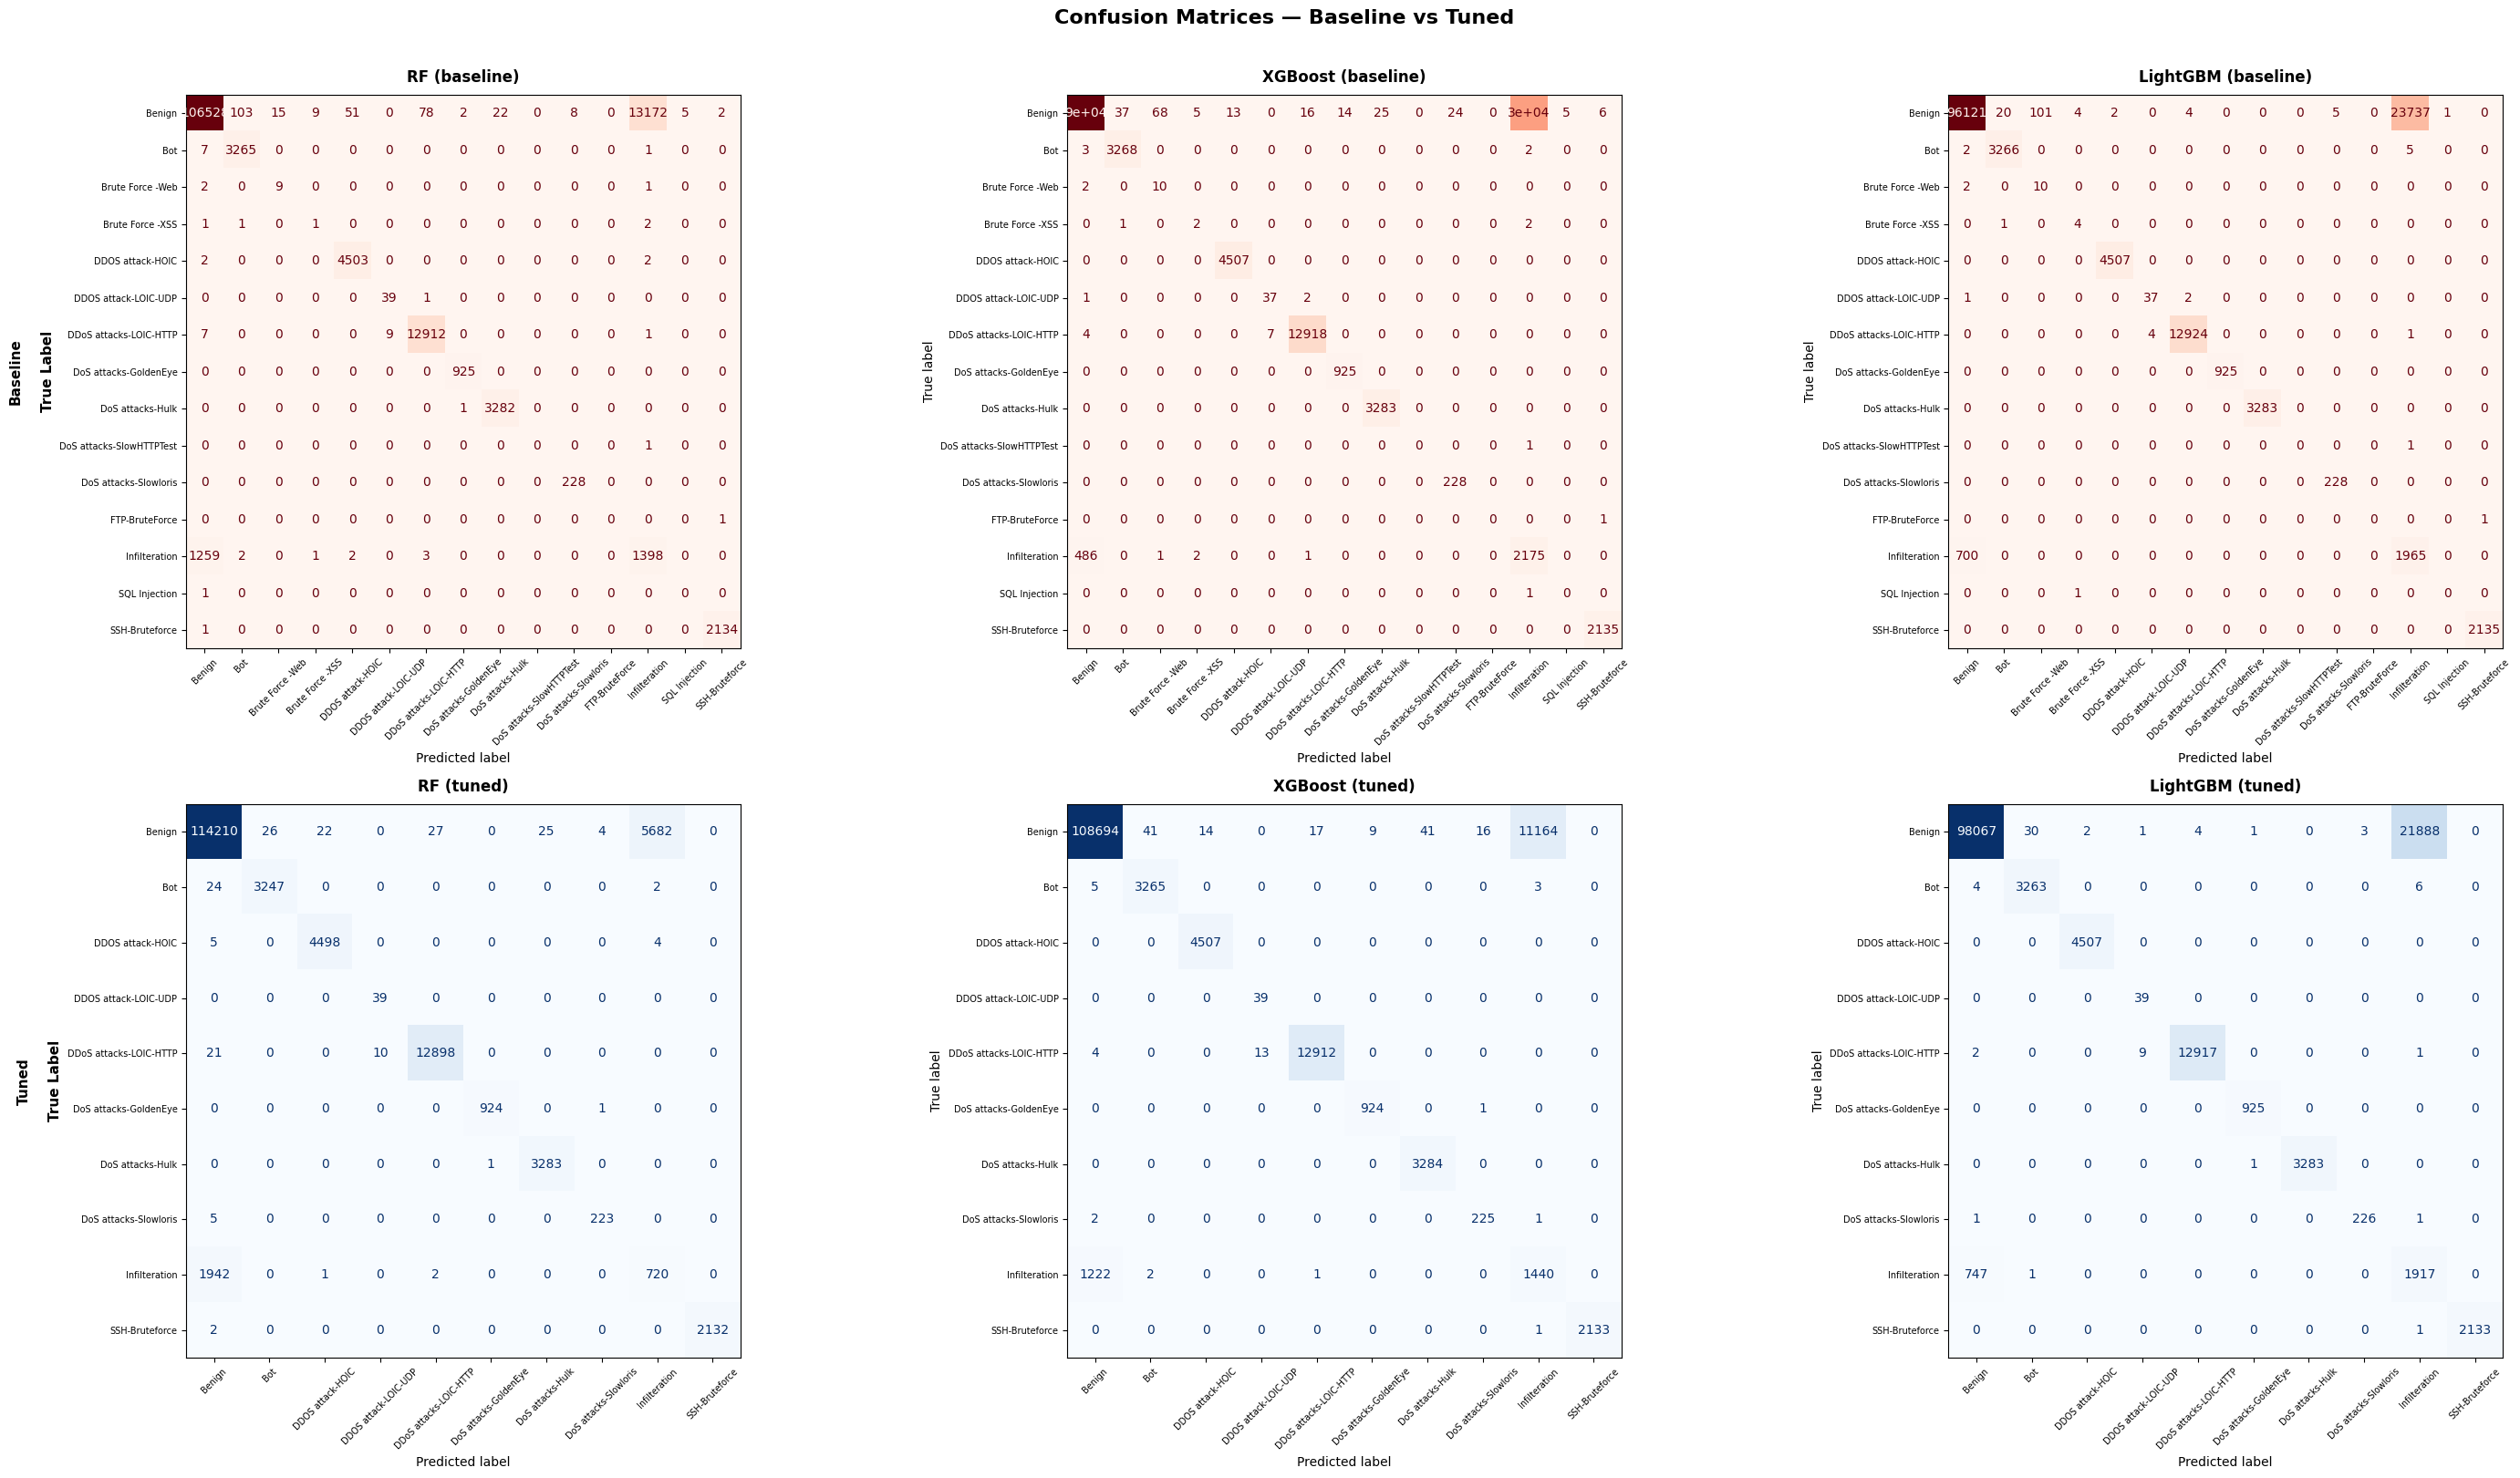

In [9]:
# ── ALL 6 CONFUSION MATRICES ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(30, 16))
fig.suptitle("Confusion Matrices — Baseline vs Tuned", fontsize=16,
             fontweight="bold", y=1.01)

# Row 1: baseline (15 classes, original le)
baseline_cms = [
    ("RF (baseline)",       rf.predict(X_test),        y_test, le.classes_),
    ("XGBoost (baseline)",  xgb_model.predict(X_test), y_test, le.classes_),
    ("LightGBM (baseline)", lgb_model.predict(X_test), y_test, le.classes_),
]
# Row 2: tuned (12 classes, le2)
tuned_cms = [
    ("RF (tuned)",       rf2.predict(X_te2),  y_te2, le2.classes_),
    ("XGBoost (tuned)",  xgb2.predict(X_te2), y_te2, le2.classes_),
    ("LightGBM (tuned)", lgb2.predict(X_te2), y_te2, le2.classes_),
]

for col, (name, y_pred, y_true, classes) in enumerate(baseline_cms):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=axes[0, col], xticks_rotation=45,
              colorbar=False, cmap="Reds")
    axes[0, col].set_title(name, fontsize=12, fontweight="bold", pad=10)
    axes[0, col].tick_params(axis="both", labelsize=7)

for col, (name, y_pred, y_true, classes) in enumerate(tuned_cms):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=axes[1, col], xticks_rotation=45,
              colorbar=False, cmap="Blues")
    axes[1, col].set_title(name, fontsize=12, fontweight="bold", pad=10)
    axes[1, col].tick_params(axis="both", labelsize=7)

# Row labels
axes[0, 0].set_ylabel("Baseline\n\nTrue Label", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Tuned\n\nTrue Label", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices_all6.png", dpi=120, bbox_inches="tight")
plt.show()


   Classical ML — Baseline vs Tuned
  RF (baseline)            : 90.15%  █████████████████████████████████████████████
  XGBoost (baseline)       : 79.44%  ███████████████████████████████████████
  LightGBM (baseline)      : 83.60%  █████████████████████████████████████████
  RF (tuned)               : 94.80%  ███████████████████████████████████████████████
  XGBoost (tuned)          : 91.63%  █████████████████████████████████████████████
  LightGBM (tuned)         : 84.86%  ██████████████████████████████████████████


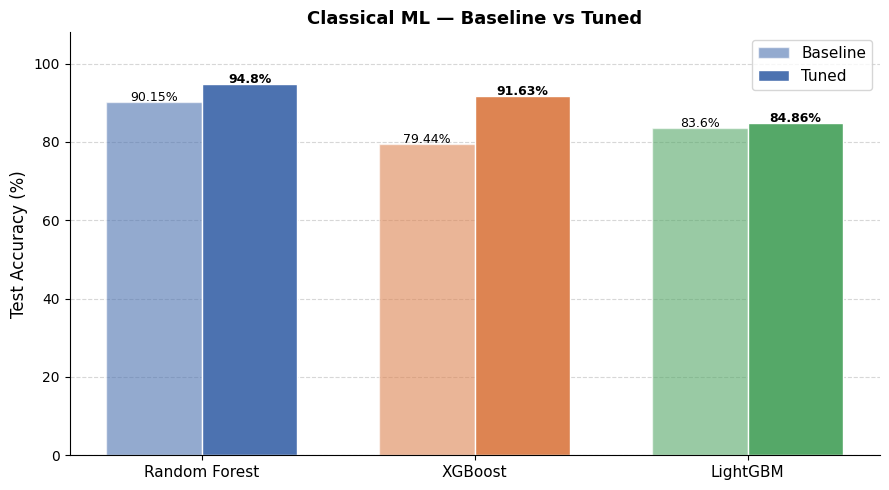

In [10]:
baseline_results = {}
for name, model, Xte, yte in [
    ("RF (baseline)",      rf,        X_test, y_test),
    ("XGBoost (baseline)", xgb_model, X_test, y_test),
    ("LightGBM (baseline)",lgb_model, X_test, y_test),
]:
    preds = model.predict(Xte)
    baseline_results[name] = round((preds == yte).mean() * 100, 2)

tuned_results = {}
for name, model, Xte, yte in [
    ("RF (tuned)",       rf2,   X_te2, y_te2),
    ("XGBoost (tuned)",  xgb2,  X_te2, y_te2),
    ("LightGBM (tuned)", lgb2,  X_te2, y_te2),
]:
    preds = model.predict(Xte)
    tuned_results[name] = round((preds == yte).mean() * 100, 2)

all_classical = {**baseline_results, **tuned_results}

print("\n" + "="*45)
print("   Classical ML — Baseline vs Tuned")
print("="*45)
for name, acc in all_classical.items():
    bar = "█" * int(acc / 2)
    print(f"  {name:<25}: {acc:.2f}%  {bar}")
print("="*45)

# Grouped bar chart
labels    = ["Random Forest", "XGBoost", "LightGBM"]
baseline  = list(baseline_results.values())
tuned     = list(tuned_results.values())
x         = np.arange(len(labels))
width     = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline, width, label="Baseline",
               color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.6, edgecolor="white")
bars2 = ax.bar(x + width/2, tuned,    width, label="Tuned",
               color=["#4C72B0", "#DD8452", "#55A868"], alpha=1.0, edgecolor="white")

ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Classical ML — Baseline vs Tuned", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars1, baseline):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9)
for bar, val in zip(bars2, tuned):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("classical_comparison_all6.png", dpi=120, bbox_inches="tight")
plt.show()

# 1st NN model -> 1 dim CNN (fine tuned)

## the helpers function for the nn based models + dropped the 15 classes to 10 (explanation above the ML codes), just like the previous finetuned ML models

In [11]:
class_weights_arr2 = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES_2), y=y_tr2)
CLASS_WEIGHTS2 = dict(enumerate(class_weights_arr2))

def compile_and_train(model, X_tr2, y_tr2, X_v2, y_v2, model_name,
                      epochs=30, batch_size=4096, lr=1e-3, class_weight=None):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    cb = [
        callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                monitor="val_loss"),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(
        X_tr2, y_tr2,
        validation_data=(X_v2, y_v2),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight if class_weight is not None else CLASS_WEIGHTS2, # this specificly for the CNN since my god this NN is deadass a beta :pray:
        callbacks=cb,
        verbose=1
    )
    return history

def evaluate_model(model, X_te2, y_te2, model_name):
    y_pred = np.argmax(model.predict(X_te2, batch_size=8192), axis=1)
    print(f"\n{'='*60}")
    print(f" {model_name} — Test Results")
    print('='*60)
    print(classification_report(y_te2, y_pred,
                                target_names=le2.classes_,   
                                zero_division=0))
    cm = confusion_matrix(y_te2, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)  
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_cm.png", dpi=100)
    plt.show()
    return y_pred

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_history.png", dpi=100)
    plt.show()

CNN class weights: {0: np.float64(0.12), 1: np.float64(0.62), 2: np.float64(0.62), 3: np.float64(0.62), 4: np.float64(0.62), 5: np.float64(0.62), 6: np.float64(0.62), 7: np.float64(0.62), 8: np.float64(0.62), 9: np.float64(0.62)}


I0000 00:00:1778240133.404124      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13677 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778240133.409217      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,850 (233.79 KB)

...

Epoch 1/50


I0000 00:00:1778240138.119185     215 service.cc:152] XLA service 0x7a54e802cd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778240138.119247     215 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778240138.119253     215 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778240138.667876     215 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/171 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.0396 - loss: 0.5480 

I0000 00:00:1778240147.638745     215 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


171/171 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.6394 - loss: 0.3650 - val_accuracy: 0.9359 - val_loss: 1.5283 - learning_rate: 3.0000e-04
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9217 - loss: 0.1022 - val_accuracy: 0.9666 - val_loss: 0.6799 - learning_rate: 3.0000e-04
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9555 - loss: 0.0623 - val_accuracy: 0.9713 - val_loss: 0.2658 - learning_rate: 3.0000e-04
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9643 - loss: 0.0514 - val_accuracy: 0.9712 - val_loss: 0.1829 - learning_rate: 3.0000e-04
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9679 - loss: 0.0459 - val_accuracy: 0.9739 - val_loss: 0.1485 - learning_rate: 3.0000e-04
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9695 - loss: 0.0423 - val_accuracy: 0.9750 - val_loss: 0.1383 - learning_rate: 3.0000e-04
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9

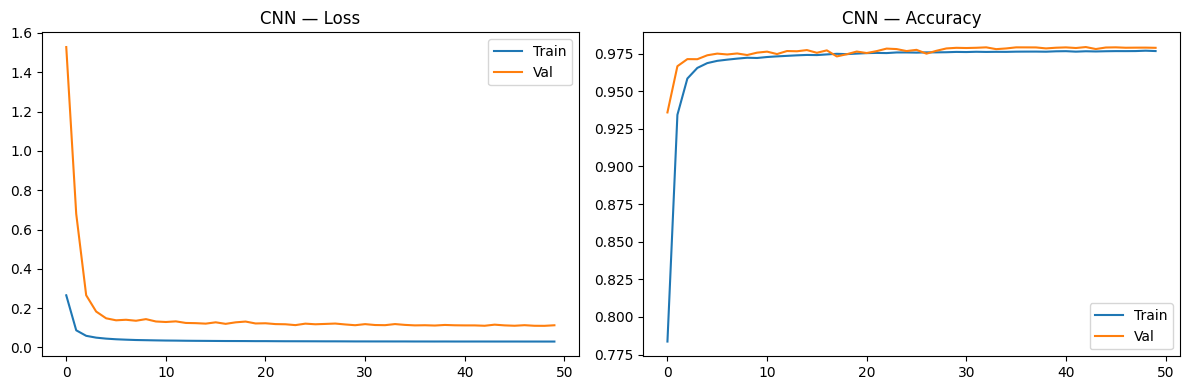

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step

 CNN — Test Results
                        precision    recall  f1-score   support

                Benign       0.98      1.00      0.99    119996
                   Bot       1.00      0.99      0.99      3273
      DDOS attack-HOIC       0.99      1.00      1.00      4507
  DDOS attack-LOIC-UDP       0.75      0.97      0.84        39
DDoS attacks-LOIC-HTTP       0.99      1.00      1.00     12929
 DoS attacks-GoldenEye       0.99      1.00      1.00       925
      DoS attacks-Hulk       0.99      1.00      0.99      3284
 DoS attacks-Slowloris       0.84      0.98      0.90       228
         Infilteration       0.28      0.05      0.09      2665
        SSH-Bruteforce       1.00      1.00      1.00      2134

              accuracy                           0.98    149980
             macro avg       0.88      0.90      0.88    149980
          weighted avg       0.97      0.98      0.97    149980



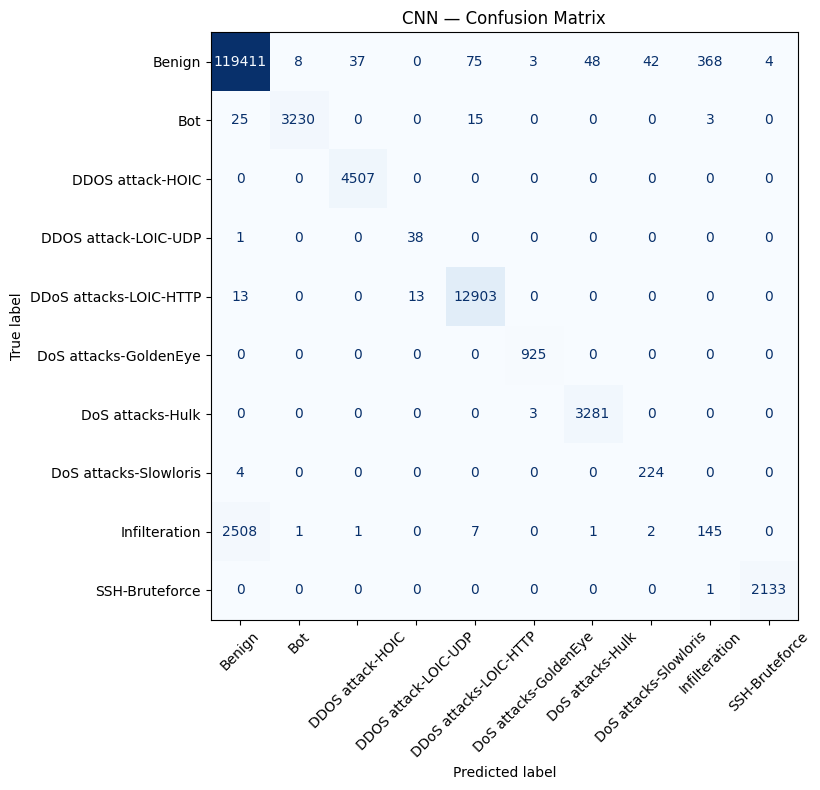

In [12]:
# 1. 1D-CNN 
import keras_tuner as kt # for tunning

def build_cnn(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim, 1))

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out, name="CNN_1D")

# Lighter class weights for CNN (BN instability fix also to try to fix the low accuracy)
cw_light = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES_2), y=y_tr2)
cw_light_capped = np.clip(cw_light, None, cw_light.min() * 5)  # 5x instead of 15x
CLASS_WEIGHTS_CNN = dict(enumerate(cw_light_capped))
print("CNN class weights:", {k: round(v, 2) for k, v in CLASS_WEIGHTS_CNN.items()})


# Reshape for CNN: (samples, features, 1)
X_train_cnn = X_tr2[..., np.newaxis]
X_val_cnn   = X_v2[..., np.newaxis]
X_test_cnn  = X_te2[..., np.newaxis]

cnn_model = build_cnn(NUM_FEATURES, NUM_CLASSES_2)
cnn_history = compile_and_train(
    cnn_model, X_train_cnn, y_tr2, X_val_cnn, y_v2, "CNN", epochs=50, lr=3e-4, class_weight=CLASS_WEIGHTS_CNN)

plot_history(cnn_history, "CNN")
evaluate_model(cnn_model, X_test_cnn, y_te2, "CNN")

cnn_model.save("cnn.keras")

# 2nd NN model: RNN-LSTM

Model: "BiLSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 77, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 77, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 77, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,818 (311.79 KB)

 Trainable params: 79,818 (311.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 44s 223ms/step - accuracy: 0.3265 - loss: 1.5953 - val_accuracy: 0.5848 - val_loss: 0.8430 - learning_rate: 0.0010
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 219ms/step - accuracy: 0.5779 - loss: 0.3760 - val_accuracy: 0.6005 - val_loss: 0.7892 - learning_rate: 0.0010
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 219ms/step - accuracy: 0.6094 - loss: 0.3645 - val_accuracy: 0.6030 - val_loss: 0.6137 - learning_rate: 0.0010
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step - accuracy: 0.6198 - loss: 0.2767 - val_accuracy: 0.6502 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 219ms/step - accuracy: 0.6202 - loss: 0.2555 - val_accuracy: 0.6195 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step - accuracy: 0.6224 - loss: 0.2386 - val_accuracy: 0.6427 - val_loss: 0.5580 - learning_rate: 0.0010
Epoch 7/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step - accuracy: 0.6

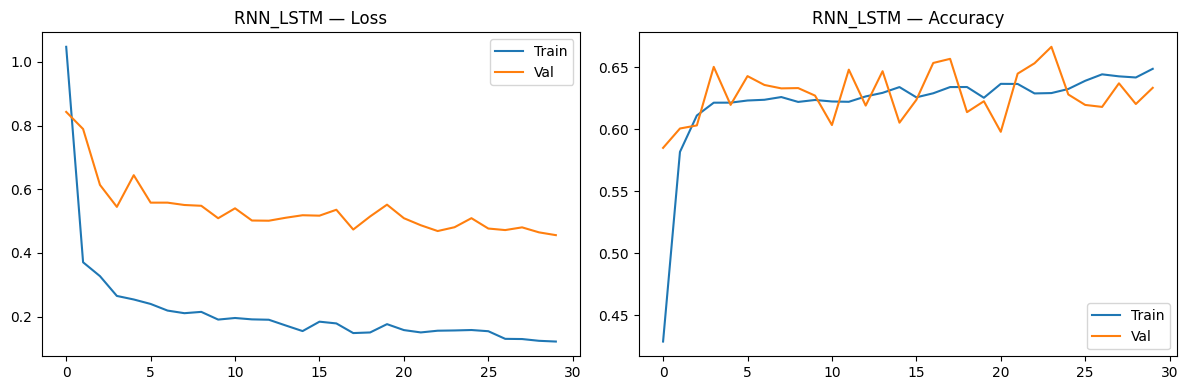

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step

 RNN_LSTM — Test Results
                        precision    recall  f1-score   support

                Benign       1.00      0.55      0.71    119996
                   Bot       0.97      0.99      0.98      3273
      DDOS attack-HOIC       0.99      1.00      1.00      4507
  DDOS attack-LOIC-UDP       0.64      1.00      0.78        39
DDoS attacks-LOIC-HTTP       0.96      1.00      0.98     12929
 DoS attacks-GoldenEye       0.77      1.00      0.87       925
      DoS attacks-Hulk       0.96      1.00      0.98      3284
 DoS attacks-Slowloris       0.39      1.00      0.56       228
         Infilteration       0.04      0.89      0.08      2665
        SSH-Bruteforce       0.99      1.00      1.00      2134

              accuracy                           0.64    149980
             macro avg       0.77      0.94      0.79    149980
          weighted avg       0.97      0.64      0.74    149980



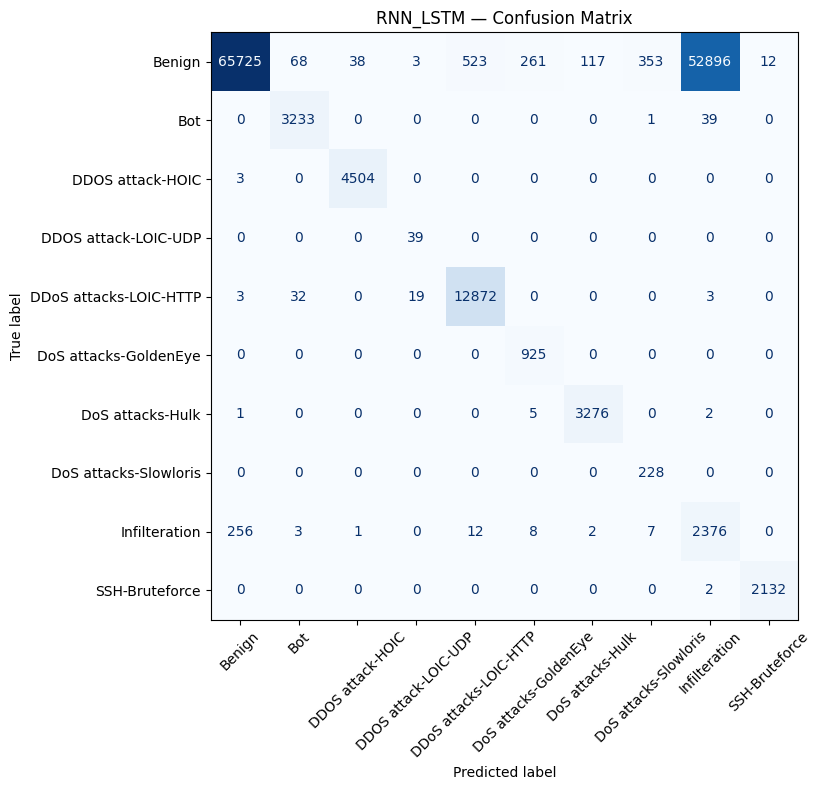

In [13]:
# 2.LSTM (RNN) 
import keras_tuner as kt
CLASS_WEIGHTS_LIGHT = CLASS_WEIGHTS_CNN  # reuse the same 5x capped weights

def build_lstm(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim, 1))

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out, name="BiLSTM_RNN")


# Reuse CNN-reshaped arrays
lstm_model = build_lstm(NUM_FEATURES, NUM_CLASSES_2)
lstm_history = compile_and_train(
    lstm_model, X_train_cnn, y_tr2, X_val_cnn, y_v2, "RNN_LSTM",  
    epochs=30, batch_size=4096)

plot_history(lstm_history, "RNN_LSTM")
evaluate_model(lstm_model, X_test_cnn, y_te2, "RNN_LSTM")  

lstm_model.save("lstm.keras")

# 3nd NN model: MLP

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,306 (247.29 KB)

 Trainable params: 62,538 (244.29 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7069 - loss: 0.2409 - val_accuracy: 0.9639 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.0706 - val_accuracy: 0.9731 - val_loss: 0.1592 - learning_rate: 0.0010
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9655 - loss: 0.0586 - val_accuracy: 0.9758 - val_loss: 0.1407 - learning_rate: 0.0010
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9685 - loss: 0.0513 - val_accuracy: 0.9760 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9696 - loss: 0.0470 - val_accuracy: 0.9770 - val_loss: 0.1296 - learning_rate: 0.0010
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9708 - loss: 0.0435 - val_accuracy: 0.9772 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9713 - loss: 0.0411 

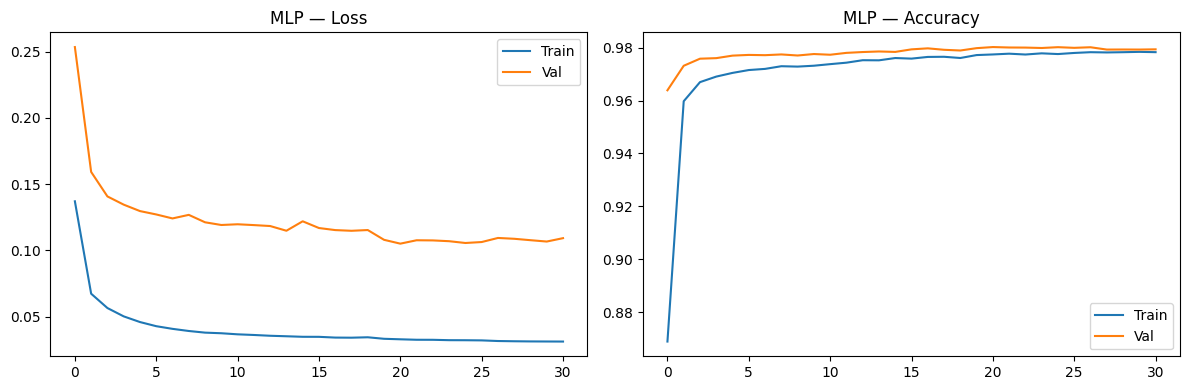

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

 MLP — Test Results
                        precision    recall  f1-score   support

                Benign       0.98      1.00      0.99    119996
                   Bot       1.00      0.99      0.99      3273
      DDOS attack-HOIC       0.99      1.00      1.00      4507
  DDOS attack-LOIC-UDP       0.75      0.97      0.84        39
DDoS attacks-LOIC-HTTP       0.99      1.00      1.00     12929
 DoS attacks-GoldenEye       0.99      1.00      1.00       925
      DoS attacks-Hulk       0.99      1.00      0.99      3284
 DoS attacks-Slowloris       0.78      0.98      0.87       228
         Infilteration       0.45      0.05      0.08      2665
        SSH-Bruteforce       1.00      1.00      1.00      2134

              accuracy                           0.98    149980
             macro avg       0.89      0.90      0.88    149980
          weighted avg       0.97      0.98      0.97    149980



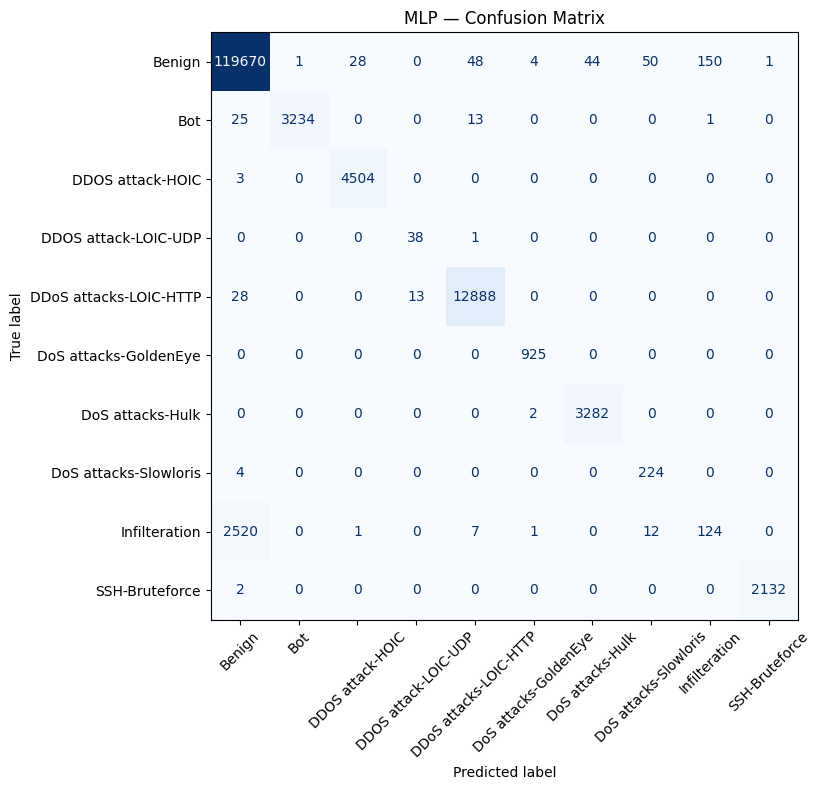

In [14]:
# 3. MLP 
CLASS_WEIGHTS_LIGHT = CLASS_WEIGHTS_CNN  # reuse the same 5x capped weights

def build_mlp(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="MLP")


mlp_model = build_mlp(NUM_FEATURES, NUM_CLASSES_2) 
mlp_history = compile_and_train(
    mlp_model, X_tr2, y_tr2, X_v2, y_v2, "MLP", epochs=50, class_weight=CLASS_WEIGHTS_LIGHT)

plot_history(mlp_history, "MLP")
evaluate_model(mlp_model, X_te2, y_te2, "MLP")

mlp_model.save("mlp.keras")

# 3 way NN Models Comparaison

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step

  NN Models Accuracy Comparison
  MLP     : 98.03%
  CNN     : 97.88%
  LSTM    : 63.55%


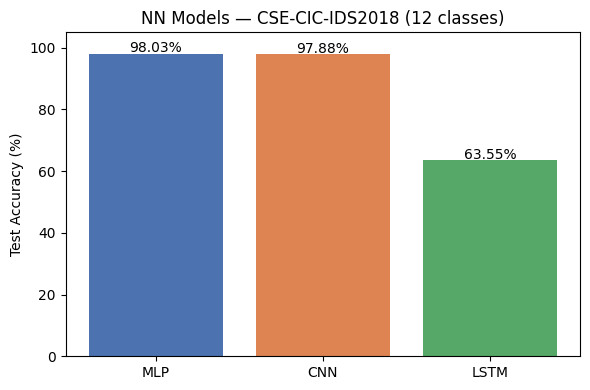


Models saved.


In [15]:
# NN based models COMPARISON
results = {}
for name, model, Xte in [("MLP",  mlp_model,  X_te2),
                          ("CNN",  cnn_model,  X_test_cnn),
                          ("LSTM", lstm_model, X_test_cnn)]:
    y_pred = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    acc = (y_pred == y_te2).mean()          # ← y_test → y_te2
    results[name] = round(acc * 100, 2)

print("\n" + "="*40)
print("  NN Models Accuracy Comparison")
print("="*40)
for name, acc in results.items():
    print(f"  {name:<8}: {acc:.2f}%")
print("="*40)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results.keys(), results.values(), color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("NN Models — CSE-CIC-IDS2018 (12 classes)")  # ← updated title
ax.set_ylim(0, 105)
for bar, val in zip(ax.patches, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f"{val}%", ha="center")
plt.tight_layout()
plt.savefig("nn_model_comparison.png", dpi=100)
plt.show()

# ── SAVE MODELS ───────────────────────────────────────────────────────────────
mlp_model.save("mlp.keras") 
cnn_model.save("cnn.keras")
lstm_model.save("lstm.keras")
print("\nModels saved.")


**before we move to sub optimal solutions, here are some quick marks about the results of the models:**

**1-CNN, MLP and rf tuned performed very well [98,98,95], tho the CNN took very significant time loss while traning unlike the RF and MLP**

**2-xgboost shows a very nice accuracy flow with a much much lower time in training compared to both rf and cnn**

**3-Gradiantboost had the weakest wheel of tunes in all showing unsignificant boost after getting fine tuned and dropped unreliable classes to be trained with, barely a 1% boost, so meaningless but still decent reuslts.**

**4- and the RNN or LSTM is basicly a model in a wheel chair, we experimented with it so long yet the best was jsut 67%, very terrible.**

**more reasons on why tho, take a look:**

RNN/LSTM sucks for 3 reasons:

Same class weight problem as the original MLP/CNN Benign recall 0.59, but fixing it would require retraining and it already took ~17 minutes per run


LSTM is fundamentally the wrong architecture for this data — flow statistics are not sequential data. There's no temporal order to the 77 features, so the LSTM's memory mechanism adds complexity without benefit. That's why CNN and MLP both demolished it


It still serves a purpose in your comparison — showing that LSTM underperforms on tabular/network flow data is actually a valid and interesting finding worth keeping

the comparison graph is down below along with the next alternatives called hybrid models.


# Hybrid model 1 : XG x CNN

Extracting CNN embeddings...
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Retraining XGBoost for hybrid...
[0]	validation_0-mlogloss:0.52934
[50]	validation_0-mlogloss:0.07144
[100]	validation_0-mlogloss:0.06567
[150]	validation_0-mlogloss:0.06506
[200]	validation_0-mlogloss:0.06495
[240]	validation_0-mlogloss:0.06494
Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7209 - loss: 0.2677 - val_accuracy: 0.9803 - val_loss: 0.1114
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9711 - loss: 0.0417 - val_accuracy: 0.9802 - val_loss: 0.1055
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9748 - loss: 0.0342 - val_accuracy: 0.9798 - val_loss: 0.1085
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9760 - loss: 0.0316 - val_accuracy: 0.9799 - val_loss: 0.1121
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9768 - loss: 0.0302 - val_

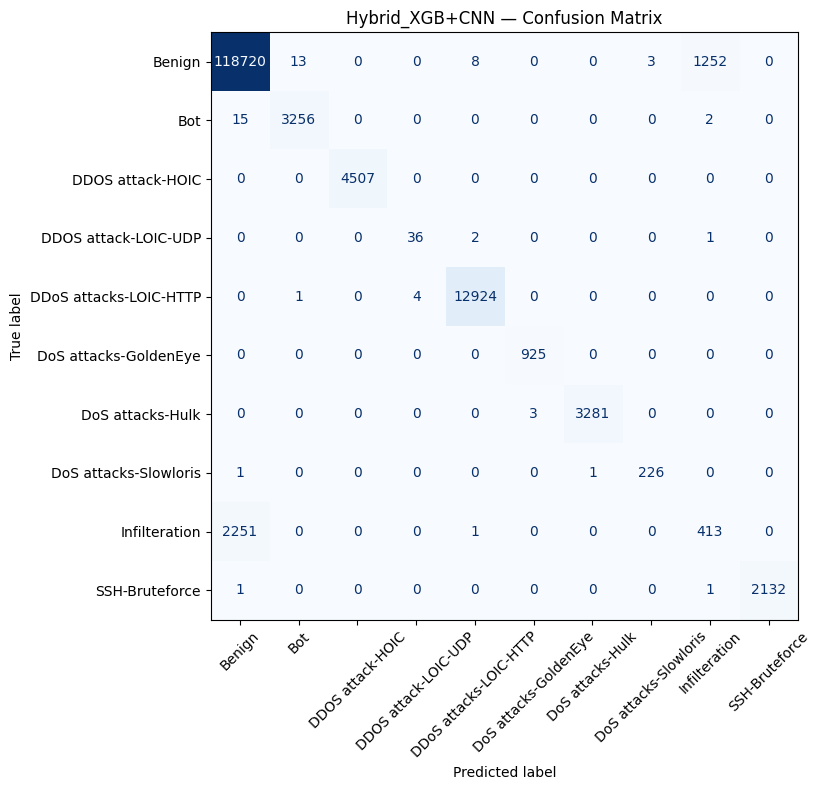

In [16]:
# ── HYBRID 1: XGBoost + CNN ───────────────────────────────────────────────────

# Step 1: CNN embeddings — uses the same cnn_model that got 98%
cnn_feat_extractor = models.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output  # layer before softmax
)
print("Extracting CNN embeddings...")
cnn_train_emb = cnn_feat_extractor.predict(X_train_cnn, batch_size=8192)
cnn_val_emb   = cnn_feat_extractor.predict(X_val_cnn,   batch_size=8192)
cnn_test_emb  = cnn_feat_extractor.predict(X_test_cnn,  batch_size=8192)

# Step 2: retrain XGB on full filtered 10-class data
print("Retraining XGBoost for hybrid...")
xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="mlogloss", tree_method="hist", device="cuda",
    random_state=SEED, early_stopping_rounds=20
)
xgb_full.fit(X_tr2, y_tr2, eval_set=[(X_v2, y_v2)], verbose=50)

xgb_train_prob = xgb_full.predict_proba(X_tr2)
xgb_val_prob   = xgb_full.predict_proba(X_v2)
xgb_test_prob  = xgb_full.predict_proba(X_te2)

# Step 3: concatenate CNN embeddings + XGB probs
X_hyb1_train = np.concatenate([cnn_train_emb, xgb_train_prob], axis=1)
X_hyb1_val   = np.concatenate([cnn_val_emb,   xgb_val_prob],   axis=1)
X_hyb1_test  = np.concatenate([cnn_test_emb,  xgb_test_prob],  axis=1)

# Step 4: meta-head — no BN (same lesson learned from CNN)
def build_meta_head(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)              # ← removed BN, dropout only
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="XGB_CNN_Hybrid")

hybrid1 = build_meta_head(X_hyb1_train.shape[1], NUM_CLASSES_2)  # ← NUM_CLASSES_2
hybrid1.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),  # ← same lr as CNN
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hybrid1.fit(
    X_hyb1_train, y_tr2,                       # ← y_train → y_tr2
    validation_data=(X_hyb1_val, y_v2),        # ← y_val → y_v2
    epochs=50,                                 # ← more epochs
    batch_size=4096,
    class_weight=CLASS_WEIGHTS_CNN,            # ← 5x cap like CNN
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
evaluate_model(hybrid1, X_hyb1_test, y_te2, "Hybrid_XGB+CNN")
hybrid1.save("hybrid1_xgb_cnn.keras")

## NOTE !!!
**THIS ONE IS GOOD 98% AND FAAAST, NOT EVEN A FULL 2 MINUTES**

# Hybrid model 2 : XG x RF x MLP (Ensemble)

Retraining RF for stacking...
Getting MLP probabilities...
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Stacked input shape: (699902, 30)
Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8472 - loss: 0.2953 - val_accuracy: 0.9641 - val_loss: 0.1018
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9736 - loss: 0.0204 - val_accuracy: 0.9625 - val_loss: 0.0985
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9744 - loss: 0.0172 - val_accuracy: 0.9624 - val_loss: 0.0983
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9746 - loss: 0.0164 - val_accuracy: 0.9625 - val_loss: 0.0981
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9747 - loss: 0.0159 - val_accuracy: 0.9624 - val_loss: 0.0970
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9745 - loss: 0.0156 - val_accuracy: 0.9616 - val_loss: 0.0976
Epoch 7/50
171/171 

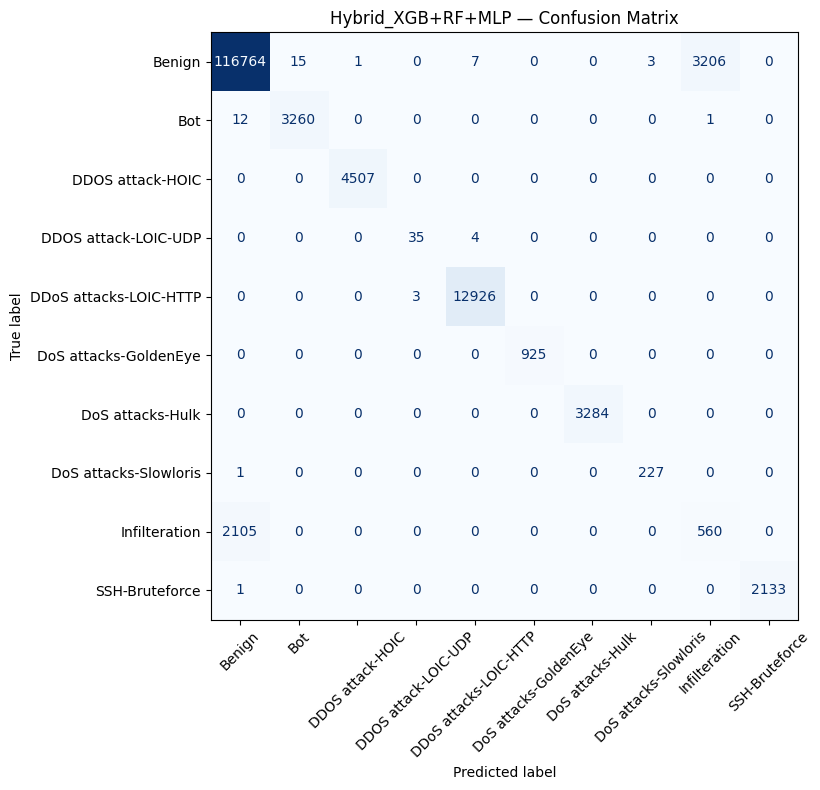

In [17]:
# ── HYBRID 2: XGBoost + RF + MLP (Stacking) ──────────────────────────────────

# RF probabilities — retrain on 10-class filtered data
print("Retraining RF for stacking...")
rf_idx2 = np.random.choice(len(X_tr2), min(500_000, len(X_tr2)), replace=False)
rf_full = RandomForestClassifier(
    n_estimators=300,               # ← tuned: more trees
    max_depth=25,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",  # ← tuned version
    n_jobs=-1,
    random_state=SEED
)
rf_full.fit(X_tr2[rf_idx2], y_tr2[rf_idx2])

rf_train_prob = rf_full.predict_proba(X_tr2)   # ← X_train → X_tr2
rf_val_prob   = rf_full.predict_proba(X_v2)    # ← X_val   → X_v2
rf_test_prob  = rf_full.predict_proba(X_te2)   # ← X_test  → X_te2

# MLP probabilities — wait for mlp_model to finish training first
print("Getting MLP probabilities...")
mlp_train_prob = mlp_model.predict(X_tr2, batch_size=8192)   # ← best_mlp → mlp_model
mlp_val_prob   = mlp_model.predict(X_v2,  batch_size=8192)
mlp_test_prob  = mlp_model.predict(X_te2, batch_size=8192)

# XGB probs — reuse xgb_full from Hybrid 1 (already trained on 10 classes)
# no need to retrain

# Stack: [XGB_probs | RF_probs | MLP_probs] → (30,) vector per sample
X_hyb2_train = np.concatenate([xgb_train_prob, rf_train_prob, mlp_train_prob], axis=1)
X_hyb2_val   = np.concatenate([xgb_val_prob,   rf_val_prob,   mlp_val_prob],   axis=1)
X_hyb2_test  = np.concatenate([xgb_test_prob,  rf_test_prob,  mlp_test_prob],  axis=1)

print(f"Stacked input shape: {X_hyb2_train.shape}")  # should be (N, 30) — 3×10 classes

# Meta-learner — deeper head since input is richer (3 models × 10 probs)
def build_meta_head2(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)  # ← wider: 128→256
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)    # ← extra layer
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="XGB_RF_MLP_Hybrid")

hybrid2 = build_meta_head2(X_hyb2_train.shape[1], NUM_CLASSES_2)  # ← NUM_CLASSES_2
hybrid2.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),   # ← same lr
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hybrid2.fit(
    X_hyb2_train, y_tr2,                        # ← y_train → y_tr2
    validation_data=(X_hyb2_val, y_v2),         # ← y_val → y_v2
    epochs=50,
    batch_size=4096,
    class_weight=CLASS_WEIGHTS_CNN,             # ← 5x cap
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
evaluate_model(hybrid2, X_hyb2_test, y_te2, "Hybrid_XGB+RF+MLP")
hybrid2.save("hybrid2_xgb_rf_mlp.keras")

## NOTE!!

kinda biased this one should take the crown but its kinda underperformed compared to it with the mini dataset before, still showed actaul W results 96%, witha  decent time of traning, i think sub 5 minutes, but still the same problem across aaaaaaall models, they cant identify intrusions, we kinda need another another apraoch, eh figures..

# comparison between the 2 hybrids

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

   Hybrid Models Comparison
  XGB + CNN                : 97.63%
  XGB + RF + MLP           : 96.43%


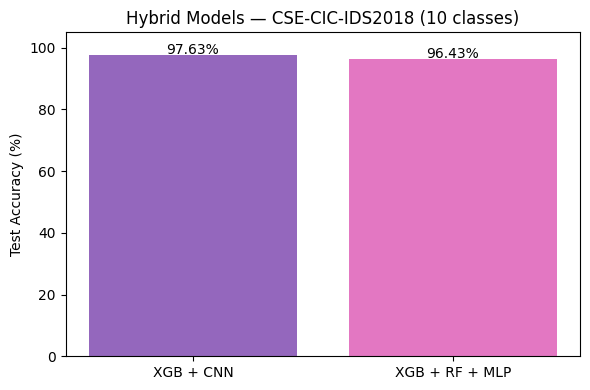

In [18]:
# ── HYBRID MODELS COMPARISON ──────────────────────────────────────────────────
hybrid_results = {}
for name, model, Xte in [
    ("XGB + CNN",      hybrid1, X_hyb1_test),
    ("XGB + RF + MLP", hybrid2, X_hyb2_test),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    hybrid_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

print("\n" + "="*40)
print("   Hybrid Models Comparison")
print("="*40)
for name, acc in sorted(hybrid_results.items(), key=lambda x: -x[1]):
    print(f"  {name:<25}: {acc:.2f}%")
print("="*40)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(hybrid_results.keys(), hybrid_results.values(),   # ← fixed broken link
              color=["#9467BD", "#E377C2"])
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Hybrid Models — CSE-CIC-IDS2018 (10 classes)")
ax.set_ylim(0, 105)
for bar, val in zip(bars, hybrid_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center")
plt.tight_layout()
plt.savefig("hybrid_comparison.png", dpi=100)
plt.show()                                                       # ← fixed broken link

# final comparison between all models:

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

        Final Model Comparison
  MLP                      : 98.03%  █████████████████████████████████████████████████
  CNN                      : 97.88%  ████████████████████████████████████████████████
  XGB + CNN                : 97.63%  ████████████████████████████████████████████████
  XGB + RF + MLP           : 96.43%  ████████████████████████████████████████████████
  RF (tuned)               : 94.80%  ███████████████████████████████████████████████
  XGBoost (tuned)          : 91.63%  █████████████████████████████████████████████
  LightGBM (tuned)         : 84.86%  ██████████████████████████████████████████
  LSTM                     : 63.55%  ███████████████████████████████


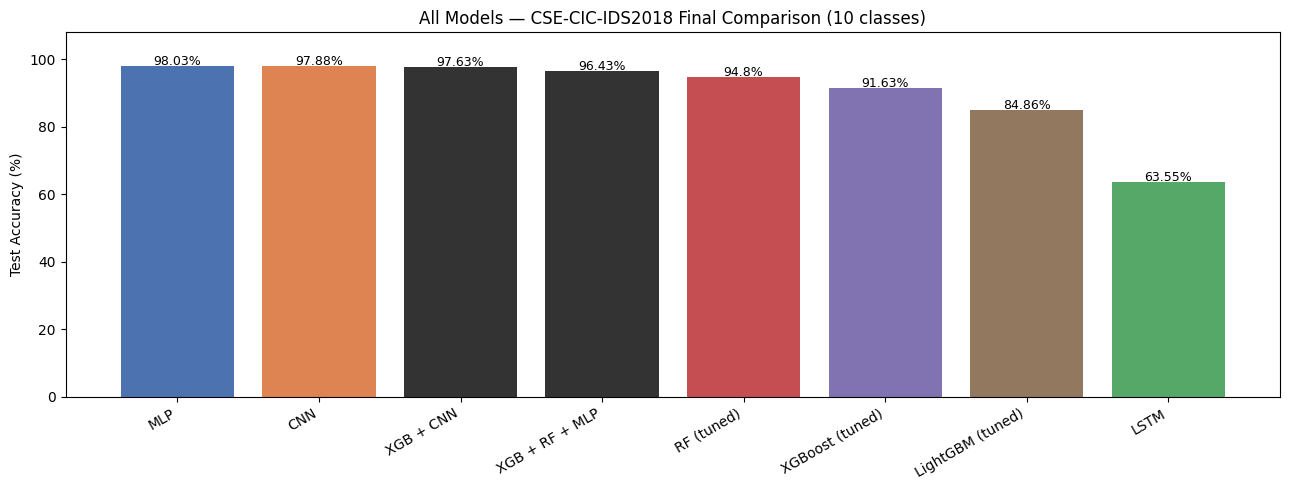

In [19]:
# ── FINAL COMPARISON — ALL MODELS ─────────────────────────────────────────────
all_results = {}

# Neural networks
for name, model, Xte in [
    ("MLP",  mlp_model,  X_te2),        # ← best_mlp → mlp_model, X_test → X_te2
    ("CNN",  cnn_model,  X_test_cnn),   # ← best_cnn → cnn_model
    ("LSTM", lstm_model, X_test_cnn),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

# Classical ML — tuned versions only for fair comparison
for name, model, Xte in [
    ("RF (tuned)",       rf2,   X_te2),
    ("XGBoost (tuned)",  xgb2,  X_te2),
    ("LightGBM (tuned)", lgb2,  X_te2),
]:
    preds = model.predict(Xte)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)

# Hybrids
for name, model, Xte in [
    ("XGB + CNN",      hybrid1, X_hyb1_test),
    ("XGB + RF + MLP", hybrid2, X_hyb2_test),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

# Sort by accuracy descending
all_results = dict(sorted(all_results.items(), key=lambda x: -x[1]))

print("\n" + "="*45)
print("        Final Model Comparison")
print("="*45)
for name, acc in all_results.items():
    bar = "█" * int(acc / 2)
    print(f"  {name:<25}: {acc:.2f}%  {bar}")
print("="*45)

colors = {
    "MLP":             "#4C72B0",
    "CNN":             "#DD8452",
    "LSTM":            "#55A868",
    "RF (tuned)":      "#C44E52",    # ← updated key names
    "XGBoost (tuned)": "#8172B2",
    "LightGBM (tuned)":"#937860",
    "H1: XGB + CNN":       "#DA8BC3",
    "H2: XGB + RF + MLP":  "#8C8C8C",
}

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [colors.get(n, "#333333") for n in all_results.keys()]
bars = ax.bar(all_results.keys(), all_results.values(), color=bar_colors)  # ← fixed broken link
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("All Models — CSE-CIC-IDS2018 Final Comparison (10 classes)")  # ← updated title
ax.set_ylim(0, 108)
plt.xticks(rotation=30, ha="right")
for bar, val in zip(bars, all_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("final_comparison_all.png", dpi=100)
plt.show()  # ← fixed broken link

final note before the next step of the operation [what is teh next step of the operation ? aaah meme]

jk jk, so hybrids werent as efficient as they were in the old dataset, but now we know that the RF CNN and MLP are the go to for the next phase of the operation hehe, ok ok time to get serious..

some Key takeaways i noticed:
the GOats (97-98%) --> CNN, MLP, XGB+CNN hybrid are essentially tied. The difference between 97.98% and 97.89% is statistically negligible on 149,980 samples that's about 135 samples difference.

Middle offs (91-95%) —-> Classical ML performed surprisingly well considering they only trained on 300K samples vs the NNs' 700K. RF at 94.80% is genuinely impressive for a tree-based model.

and the Lgbm even tuned with LSTM sucked, thats it. ik so uuuh LSTM isnt performative in this senario even at large samples and also a bigger window of traning, and the GMB needed mooore rounds for it to converge but we can just take the other 3 that worked well.

alright guys heres what you should do EXACTLY, NO PHUSE NO MUSS:

- Classical ML (baseline + tuned) [done]
- NN models (CNN, MLP, LSTM) [done]
- Hybrid models  [done]
- Feature engineering
- Binary Infilteration detector
- Retrain everything with enriched features

good luck and have fun

hi youssef here and we are doing the 
Feature engineering
Binary Infilteration detector
Retrain everything with enriched features
part 
and we are gonna start with :


# **Feauture Enginnering**

In [27]:
# ============================================================
# FEATURE ENGINEERING — HYBRID XGB+CNN ONLY
# ============================================================

TARGET_ATTACK = "Infilteration"
INFILTERATION_WEIGHT_MULTIPLIER_FE = 2.0  # lower = less Benign confused as Infilteration
HYBRID_EPOCHS_FE = 50
BATCH_SIZE_FE = 4096

# ── 1. Rebuild filtered dataframe ──────────────────────────
feature_cols_original_fe = (
    df.drop(columns=[LABEL_COL])
      .select_dtypes(include=[np.number])
      .columns.tolist()
)
df_filtered_fe = pd.DataFrame(X_filtered, columns=feature_cols_original_fe)
df_filtered_fe[LABEL_COL] = y_raw_filtered

# ── 2. Feature engineering ─────────────────────────────────
def add_enriched_features(data, numeric_columns):
    data = data.copy()
    eps = 1e-6

    for col in numeric_columns:
        if col in data.columns and data[col].min() >= 0:
            data[f"log1p_{col}"] = np.log1p(data[col])

    ratio_pairs = [
        ("Tot Fwd Pkts","Tot Bwd Pkts"),
        ("TotLen Fwd Pkts","TotLen Bwd Pkts"),
        ("Fwd Pkt Len Mean","Bwd Pkt Len Mean"),
        ("Fwd Pkt Len Max","Bwd Pkt Len Max"),
        ("Fwd IAT Mean","Bwd IAT Mean"),
        ("Fwd IAT Total","Bwd IAT Total"),
        ("Fwd Header Len","Bwd Header Len"),
        ("Subflow Fwd Pkts","Subflow Bwd Pkts"),
        ("Subflow Fwd Byts","Subflow Bwd Byts"),
    ]
    for a, b in ratio_pairs:
        if a in data.columns and b in data.columns:
            data[f"ratio_{a}_over_{b}"] = data[a] / (data[b] + eps)
            data[f"diff_{a}_minus_{b}"] = data[a] - data[b]
            data[f"sum_{a}_{b}"]        = data[a] + data[b]

    if "Flow Duration" in data.columns:
        for col in ["Tot Fwd Pkts","Tot Bwd Pkts","TotLen Fwd Pkts","TotLen Bwd Pkts"]:
            if col in data.columns:
                data[f"{col}_per_duration"] = data[col] / (data["Flow Duration"] + eps)

    if "Flow Byts/s" in data.columns and "Flow Pkts/s" in data.columns:
        data["bytes_per_packet_rate"] = data["Flow Byts/s"] / (data["Flow Pkts/s"] + eps)

    if "Pkt Len Std" in data.columns and "Pkt Len Mean" in data.columns:
        data["pkt_len_cv"] = data["Pkt Len Std"] / (data["Pkt Len Mean"] + eps)
    if "Pkt Len Max" in data.columns and "Pkt Len Min" in data.columns:
        data["pkt_len_range"] = data["Pkt Len Max"] - data["Pkt Len Min"]

    flag_cols = ["FIN Flag Cnt","SYN Flag Cnt","RST Flag Cnt","PSH Flag Cnt",
                 "ACK Flag Cnt","URG Flag Cnt","CWE Flag Count","ECE Flag Cnt"]
    existing_flags = [c for c in flag_cols if c in data.columns]
    if existing_flags:
        data["total_tcp_flags"]  = data[existing_flags].sum(axis=1)
        data["has_any_tcp_flag"] = (data["total_tcp_flags"] > 0).astype(int)
    if "SYN Flag Cnt" in data.columns and "ACK Flag Cnt" in data.columns:
        data["syn_ack_ratio"] = data["SYN Flag Cnt"] / (data["ACK Flag Cnt"] + eps)
    if "RST Flag Cnt" in data.columns and "ACK Flag Cnt" in data.columns:
        data["rst_ack_ratio"] = data["RST Flag Cnt"] / (data["ACK Flag Cnt"] + eps)
    if "FIN Flag Cnt" in data.columns and "SYN Flag Cnt" in data.columns:
        data["fin_syn_ratio"] = data["FIN Flag Cnt"] / (data["SYN Flag Cnt"] + eps)

    # Infilteration-specific
    if "Flow Pkts/s" in data.columns:
        data["is_low_pkt_rate"] = (data["Flow Pkts/s"] < 10).astype(int)
    if "Pkt Len Mean" in data.columns:
        data["is_tiny_payload"] = (data["Pkt Len Mean"] < 100).astype(int)
    if "Flow Duration" in data.columns and "Tot Fwd Pkts" in data.columns:
        data["duration_per_fwd_pkt"] = data["Flow Duration"] / (data["Tot Fwd Pkts"] + eps)
        data["is_slow_scan"] = (
            (data["Flow Duration"] > 1e6) & (data["Tot Fwd Pkts"] < 10)
        ).astype(int)
    if "Tot Bwd Pkts" in data.columns:
        data["is_one_way"] = (data["Tot Bwd Pkts"] == 0).astype(int)
    if "Tot Fwd Pkts" in data.columns and "Tot Bwd Pkts" in data.columns:
        data["fwd_bwd_pkt_asymmetry"] = data["Tot Fwd Pkts"] / (
            data["Tot Fwd Pkts"] + data["Tot Bwd Pkts"] + eps)
    if "SYN Flag Cnt" in data.columns and "ACK Flag Cnt" in data.columns:
        data["ack_no_syn"] = (
            (data["ACK Flag Cnt"] > 0) & (data["SYN Flag Cnt"] == 0)
        ).astype(int)
    if "TotLen Fwd Pkts" in data.columns and "Tot Fwd Pkts" in data.columns:
        data["zero_payload_fwd"] = (
            (data["TotLen Fwd Pkts"] == 0) & (data["Tot Fwd Pkts"] > 0)
        ).astype(int)

    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.fillna(0, inplace=True)
    return data

# ── 3. Apply FE ────────────────────────────────────────────
numeric_cols_fe = (
    df_filtered_fe.drop(columns=[LABEL_COL])
                  .select_dtypes(include=[np.number])
                  .columns.tolist()
)
df_best_fe = add_enriched_features(df_filtered_fe, numeric_cols_fe)
feature_cols_best_fe = (
    df_best_fe.drop(columns=[LABEL_COL])
              .select_dtypes(include=[np.number])
              .columns.tolist()
)
print("Original features:", len(numeric_cols_fe))
print("Enriched features:", len(feature_cols_best_fe))

# ── 4. Encode + split ──────────────────────────────────────
le_best_fe = LabelEncoder()
y_best_fe  = le_best_fe.fit_transform(df_best_fe[LABEL_COL])
X_best_fe  = df_best_fe[feature_cols_best_fe].values.astype(np.float32)

NUM_CLASSES_BEST_FE  = len(le_best_fe.classes_)
NUM_FEATURES_BEST_FE = X_best_fe.shape[1]
print("Classes:", le_best_fe.classes_)

X_train_best_fe, X_tmp, y_train_best_fe, y_tmp = train_test_split(
    X_best_fe, y_best_fe, test_size=0.30, random_state=SEED, stratify=y_best_fe)
X_val_best_fe, X_test_best_fe, y_val_best_fe, y_test_best_fe = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# ── 5. Scale ───────────────────────────────────────────────
scaler_best_fe = StandardScaler()
X_train_best_fe = scaler_best_fe.fit_transform(X_train_best_fe)
X_val_best_fe   = scaler_best_fe.transform(X_val_best_fe)
X_test_best_fe  = scaler_best_fe.transform(X_test_best_fe)

# ── 6. Class weights ───────────────────────────────────────
class_weights_arr = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES_BEST_FE), y=y_train_best_fe)
class_weights_arr = np.clip(class_weights_arr, None, class_weights_arr.min() * 8)
CLASS_WEIGHTS_BEST_FE = dict(enumerate(class_weights_arr))
infilteration_id_best_fe = np.where(le_best_fe.classes_ == TARGET_ATTACK)[0][0]
CLASS_WEIGHTS_BEST_FE[infilteration_id_best_fe] *= INFILTERATION_WEIGHT_MULTIPLIER_FE
print("Infilteration weight:", round(CLASS_WEIGHTS_BEST_FE[infilteration_id_best_fe], 3))

# ── 7. Train XGB on enriched features ─────────────────────
from xgboost import XGBClassifier
xgb_fe = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.1, device="cpu",
    random_state=SEED, eval_metric="mlogloss"
)
xgb_fe.fit(X_train_best_fe, y_train_best_fe)

xgb_train_prob_fe = xgb_fe.predict_proba(X_train_best_fe)
xgb_val_prob_fe   = xgb_fe.predict_proba(X_val_best_fe)
xgb_test_prob_fe  = xgb_fe.predict_proba(X_test_best_fe)

# ── 8. Build hybrid input ──────────────────────────────────
X_hybrid_train_fe = np.concatenate([X_train_best_fe, xgb_train_prob_fe], axis=1)
X_hybrid_val_fe   = np.concatenate([X_val_best_fe,   xgb_val_prob_fe],   axis=1)
X_hybrid_test_fe  = np.concatenate([X_test_best_fe,  xgb_test_prob_fe],  axis=1)

X_hybrid_train_fe_cnn = X_hybrid_train_fe[..., np.newaxis]
X_hybrid_val_fe_cnn   = X_hybrid_val_fe[..., np.newaxis]
X_hybrid_test_fe_cnn  = X_hybrid_test_fe[..., np.newaxis]

# ── 9. Train Hybrid CNN ────────────────────────────────────
hybrid_xgb_cnn_fe = build_cnn(X_hybrid_train_fe.shape[1], NUM_CLASSES_BEST_FE)
hybrid_xgb_cnn_fe.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
_ = hybrid_xgb_cnn_fe.fit(
    X_hybrid_train_fe_cnn, y_train_best_fe,
    validation_data=(X_hybrid_val_fe_cnn, y_val_best_fe),
    epochs=HYBRID_EPOCHS_FE, batch_size=BATCH_SIZE_FE,
    class_weight=CLASS_WEIGHTS_BEST_FE, verbose=1)

print("✅ Hybrid XGB+CNN FE trained.")

Original features: 77
Enriched features: 153
Classes: ['Benign' 'Bot' 'DDOS attack-HOIC' 'DDOS attack-LOIC-UDP'
 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye' 'DoS attacks-Hulk'
 'DoS attacks-Slowloris' 'Infilteration' 'SSH-Bruteforce']
Infilteration weight: 2.0
Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.7603 - loss: 0.3816 - val_accuracy: 0.9221 - val_loss: 1.0444
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9387 - loss: 0.0892 - val_accuracy: 0.9190 - val_loss: 0.6466
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.9502 - loss: 0.0675 - val_accuracy: 0.6993 - val_loss: 0.4845
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9486 - loss: 0.0583 - val_accuracy: 0.9294 - val_loss: 0.2844
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.9469 - loss: 0.0514 - val_accuracy: 0.9498 - val_loss: 0.1767
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9430 - loss: 0.

# CELL 2 — Evaluation + Guard + All Plots

Tuning guard on validation set...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
19/19 

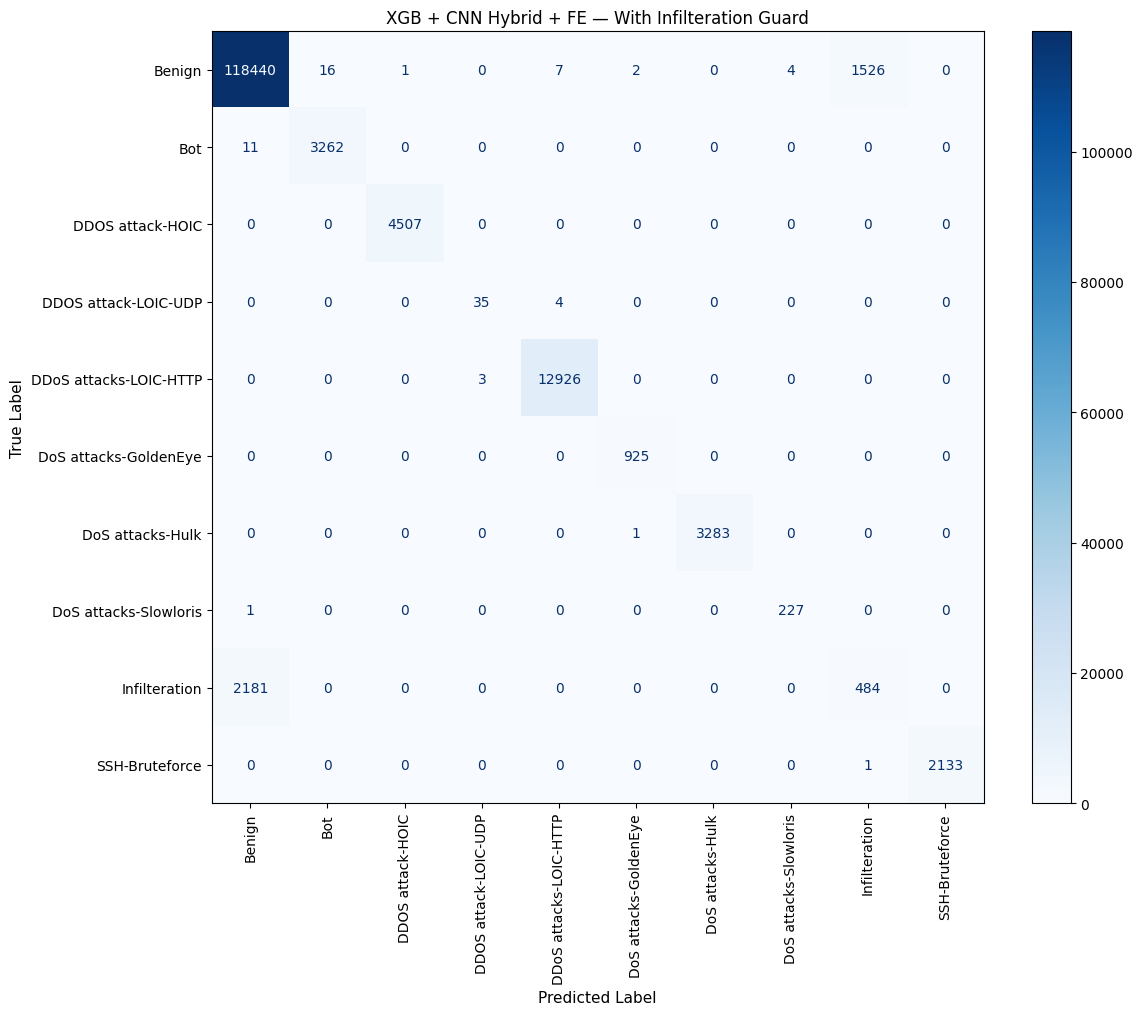

✅ Done. Model saved.


In [28]:
# ============================================================
# FEATURE ENGINEERING — CELL 2: EVALUATION + GUARD + PLOT
# ============================================================

def predict_with_guard(model, X_data, threshold, margin):
    probs     = model.predict(X_data[..., np.newaxis], batch_size=8192)
    target_id = np.where(le_best_fe.classes_ == TARGET_ATTACK)[0][0]
    benign_id = np.where(le_best_fe.classes_ == "Benign")[0][0]
    preds     = np.argmax(probs, axis=1)
    for i in range(len(preds)):
        if preds[i] == target_id:
            if (probs[i, target_id] < threshold or
                    (probs[i, target_id] - probs[i, benign_id]) < margin):
                tmp = probs[i].copy()
                tmp[target_id] = -1
                preds[i] = np.argmax(tmp)
    return preds

def tune_guard(model, X_val, y_val, min_recall=0.55):
    target_id = np.where(le_best_fe.classes_ == TARGET_ATTACK)[0][0]
    benign_id = np.where(le_best_fe.classes_ == "Benign")[0][0]
    best_config, best_score = None, -1
    for threshold in [0.30,0.40,0.50,0.55,0.60,0.65,0.70,0.75,0.80]:
        for margin in [0.00,0.05,0.10,0.15,0.20,0.25,0.30]:
            y_pred_v = predict_with_guard(model, X_val, threshold, margin)
            cm       = confusion_matrix(y_val, y_pred_v)
            tp  = cm[target_id, target_id]
            fn  = cm[target_id, :].sum() - tp
            fp  = cm[:, target_id].sum() - tp
            b2i = cm[benign_id, target_id]
            recall    = tp / (tp + fn + 1e-9)
            precision = tp / (tp + fp + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)
            if recall >= min_recall:
                score = f1 - (b2i / len(y_val))
                if score > best_score:
                    best_score  = score
                    best_config = {
                        "threshold": threshold, "margin": margin,
                        "precision": round(precision, 4),
                        "recall":    round(recall, 4),
                        "f1":        round(f1, 4),
                        "benign_to_infilteration": int(b2i)
                    }
    if best_config is None:
        best_config = {"threshold": 0.70, "margin": 0.20,
                       "precision": None, "recall": None,
                       "f1": None, "benign_to_infilteration": None}
    return best_config

# ── Tune guard ─────────────────────────────────────────────
print("Tuning guard on validation set...")
best_guard = tune_guard(hybrid_xgb_cnn_fe, X_hybrid_val_fe, y_val_best_fe)
print("Best guard config:", best_guard)

# ── Predict with guard ─────────────────────────────────────
y_pred_final = predict_with_guard(
    hybrid_xgb_cnn_fe, X_hybrid_test_fe,
    best_guard["threshold"], best_guard["margin"])

# ── Report ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print("XGB + CNN Hybrid + FE — Final Results With Infilteration Guard")
print("=" * 70)
print(classification_report(
    y_test_best_fe, y_pred_final,
    target_names=le_best_fe.classes_, zero_division=0))

report = classification_report(
    y_test_best_fe, y_pred_final,
    target_names=le_best_fe.classes_, zero_division=0, output_dict=True)

if TARGET_ATTACK in report:
    r = report[TARGET_ATTACK]
    print(f"INFILTERATION → Precision:{round(r['precision'],4)}  "
          f"Recall:{round(r['recall'],4)}  F1:{round(r['f1-score'],4)}")

# ── Confusion matrix ───────────────────────────────────────
cm = confusion_matrix(y_test_best_fe, y_pred_final)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=le_best_fe.classes_).plot(
    ax=ax, xticks_rotation=90, values_format="d", cmap="Blues")
ax.set_title("XGB + CNN Hybrid + FE — With Infilteration Guard")
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()

# ── Save ───────────────────────────────────────────────────
hybrid_xgb_cnn_fe.save("hybrid_xgb_cnn_feature_engineering.keras")
print("✅ Done. Model saved.")